In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
torch.manual_seed(0)

## Negative log likelihood

$$-\log(P)$$

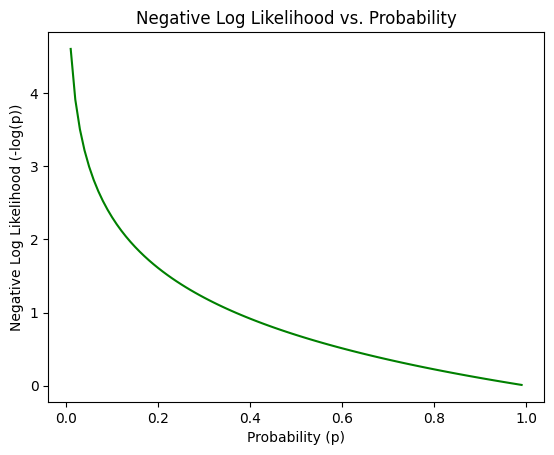

In [9]:
p = torch.arange(0, 100) / 100.0
nll = -p.log()
plot1 = plt.plot(
    p.tolist(), 
    nll.tolist(), 
    '-g', 
    label="log(x)",
)
plt.xlabel('Probability (p)')
plt.ylabel('Negative Log Likelihood (-log(p))')
plt.title('Negative Log Likelihood vs. Probability')
plt.show()
# p increases, -log(p) decreases
# Goal: maximize p
# <=> minimize -log(p)

## Cross entropy

$$
H(p, q) = -\sum_{x} p(x) \log(q(x))
$$

Where $p$ is the true distribution and $q$ is the predicted distribution.

In [4]:
p, q = 0.9, 0.5
entropy = -p * math.log(q)
print(entropy)

0.6238324625039507


In [5]:
q = torch.tensor([0.1, 0.8, 0.1]) # prediction
p = torch.tensor([0.0, 1, 0.0]) # target
e = -p * torch.log(q)
print(e)
print(e.sum())

tensor([0.0000, 0.2231, 0.0000])
tensor(0.2231)


In [6]:
# If it is a classification problem,
# only one of p is 1, the rest are 0.
q = torch.tensor([0.1, 0.8, 0.1]) # prediction
label = 1
e = -torch.log(q[label])
print(e)

tensor(0.2231)


## Cross entropy loss

In [7]:
def cross_entropy(q, p):
    p = F.one_hot(p, num_classes=q.size(1)).float()
    q = F.softmax(q, dim=1)
    print(p.shape, q.shape)
    print(p)
    print(q)
    return (-p * torch.log(q)).sum() / p.size(0)

pred = torch.randn(2, 10)
target = torch.randint(0, 10, (2,))
ce = cross_entropy(pred, target)
ce2 = F.cross_entropy(pred, target)
print(ce)
print(ce2)
print(torch.allclose(ce, ce2))

torch.Size([2, 10]) torch.Size([2, 10])
tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])
tensor([[0.0238, 0.0232, 0.0571, 0.0475, 0.1334, 0.0155, 0.0521, 0.4677, 0.1171,
         0.0626],
        [0.1324, 0.0408, 0.1254, 0.1527, 0.0805, 0.0134, 0.0794, 0.1101, 0.2322,
         0.0330]])
tensor(3.1375)
tensor(3.1375)
True
